In [4]:
def f(x):
    return x**2 -4 * x + 4

In [5]:
def df(x):
    return 2*x-4

In [14]:
def gd(init, lr, n):#, f, df):
    x = init
    lst = [x] # to store the history of x values
    for i in range(n): #, f, df):
        g = df(x) # compute the gradient at the current x
        x = x - lr * g # update x using the gradient descent formula
        lst.append(x) # store the new x value in the list

    return x, lst   # return the final x value and the history of x values

In [16]:
gd( 1, 0.1, 3) # (0.8, [0, 0.4, 0.64, 0.768]) 

(1.488, [1, 1.2, 1.3599999999999999, 1.488])

In [17]:
gd(0, 0.5, 1)

(2.0, [0, 2.0])

In [9]:
import numpy as np
import matplotlib.pyplot as plt

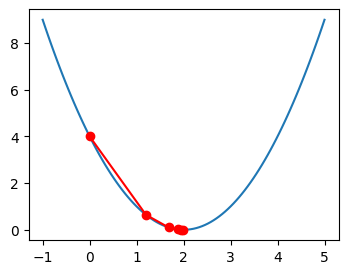

In [ ]:
xf, h = gd(0, 0.3, 5) #

xv = np.linspace(-1, 5, 100)    # create a range of x values from -1 to 5
yv = f(xv) # compute the corresponding y values using the function f

hx = np.array(h)
hy = f(hx)

plt.figure(figsize=(4, 3))
plt.plot(xv, yv)
plt.plot(hx, hy, color='red', marker='o')
plt.show()

In [13]:
hx

array([0.     , 1.2    , 1.68   , 1.872  , 1.9488 , 1.97952])

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  نکات ۱ و ۵ — محدب بودن MSE  +  جهت بردار گرادیان
#
#  نکته ۱: تابع هزینه MSE در رگرسیون خطی همواره کاملاً محدب (Convex) است.
#           فضای پارامترها شبیه یک کاسه بی‌نقص است — هیچ مینیمم محلی ندارد.
#           هر مینیممی که گرادیان کاهشی بیابد، قطعاً مینیمم مطلق (Global) است.
#
#  نکته ۵: بردار گرادیان (∇J) در هر نقطه از فضای پارامترها،
#           همواره به سمت شیب‌دارترین مسیر صعود (بالا رفتن) اشاره می‌کند.
#           الگوریتم گرادیان کاهشی در خلاف جهت این بردار حرکت می‌کند (= پایین می‌رود).
# ══════════════════════════════════════════════════════════════════════════════

# ── ساخت فضای نمایش: ۳ نمودار کنار هم ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
# عنوان کلی پنجره
fig.suptitle("Note 1 & 5 — MSE is Convex | Gradient Always Points Uphill",
             fontsize=13, fontweight="bold")

# ── نمودار چپ: کاسه دو‌بعدی (یک پارامتر W) ─────────────────────────────────
ax = axes[0]

# محور افقی: مقادیر مختلف W از -3 تا 7
W_vals = np.linspace(-3, 7, 300)
# تابع هزینه ساده: J(W) = (W-2)² — پارابولا با مینیمم در W=2
# این فرم ساده‌شده MSE است برای نمایش محدب بودن
J_vals = (W_vals - 2) ** 2

# رسم منحنی تابع هزینه با خط مشکی ضخیم
ax.plot(W_vals, J_vals, "k-", linewidth=2.5, label="J(W) — MSE cost")
ax.set_xlabel("W  (weight parameter)")  # برچسب محور افقی: مقدار وزن
ax.set_ylabel("J(W)  (cost)")           # برچسب محور عمودی: مقدار هزینه
ax.set_title("2-D Convex Bowl\n(one parameter)")  # عنوان نمودار

# نشان‌گذاری نقطه مینیمم با خط عمودی قرمز در W=2
ax.axvline(2, color="red", linestyle="--", linewidth=1.5, label="W* = 2 (global min)")
# نقطه قرمز دقیقاً روی کف کاسه (W=2, J=0)
ax.scatter([2], [0], color="red", s=100, zorder=6)
# توضیح متنی با فلش به سمت مینیمم
ax.annotate("Global\nMinimum\n(only one!)",
            xy=(2, 0),           # مختصات نوک فلش = نقطه مینیمم
            xytext=(3.5, 3),     # مختصات متن توضیحی
            arrowprops=dict(arrowstyle="->", color="red"), fontsize=9, color="red")

# ── رسم فلش‌های گرادیان در دو طرف کاسه ─────────────────────────────────────
# هدف: نشان دادن اینکه گرادیان همواره به سمت بالا اشاره می‌کند
for W_pt, direction in [(-1, -1), (5, 1)]:  # -1 = سمت چپ، +1 = سمت راست
    grad = 2 * (W_pt - 2)        # محاسبه گرادیان: ∇J(W) = 2·(W-2) = d/dW[(W-2)²]
    J_pt = (W_pt - 2) ** 2       # مقدار تابع هزینه در این نقطه

    # رسم فلش نارنجی از نقطه فعلی به سمت بالا (جهت گرادیان = صعود)
    ax.annotate("",
                xy     =(W_pt + 0.8*np.sign(grad), J_pt + 0.8*abs(grad)),  # نوک فلش (بالاتر)
                xytext =(W_pt, J_pt),   # پایه فلش (نقطه فعلی)
                arrowprops=dict(arrowstyle="->", color="darkorange", lw=2))
    # برچسب متنی کنار فلش
    ax.text(W_pt + 0.1*np.sign(grad), J_pt + 0.5, "∇J\n(uphill)",
            fontsize=8, color="darkorange", ha="center")

ax.legend(fontsize=8)
ax.set_ylim(-1, 28)  # محدوده محور عمودی
# جعبه توضیحات: خلاصه مفهوم در گوشه نمودار
ax.text(0.02, 0.97,
        "Key: bowl shape = CONVEX\n"                  # شکل کاسه = محدب
        "→ no local minima exist\n"                   # مینیمم محلی وجود ندارد
        "→ gradient always leads to\n"                # گرادیان همیشه می‌برد به
        "   the same global minimum\n"                # همان مینیمم مطلق
        "Orange arrows = gradient ∇J\n"               # فلش نارنجی = گرادیان
        "  (always points UPHILL)",                   # همیشه به بالا اشاره دارد
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── نمودار میانی: سطح سه‌بعدی J(W, B) ──────────────────────────────────────
# این نمودار نشان می‌دهد که با دو پارامتر هم، کاسه محدب است
ax_mid = fig.add_subplot(1, 3, 2, projection="3d")  # نمودار سه‌بعدی در وسط

# ساخت شبکه مختصات برای W و B
W_grid = np.linspace(-2, 6, 60)  # 60 نقطه برای W از -2 تا 6
B_grid = np.linspace(-2, 6, 60)  # 60 نقطه برای B از -2 تا 6
WW, BB = np.meshgrid(W_grid, B_grid)  # ساخت ماتریس دوبعدی از تمام ترکیبات W و B

# محاسبه تابع هزینه برای همه ترکیبات W و B
# J(W,B) = (W-2)² + (B-1)² — دو پارابولا که با هم جمع شده‌اند
# مینیمم در W*=2, B*=1 است که J=0 می‌دهد
JJ = (WW - 2)**2 + (BB - 1)**2

# رسم سطح سه‌بعدی با رنگ‌بندی گرما (آبی=کم، قرمز=زیاد)
surf = ax_mid.plot_surface(WW, BB, JJ,
                            cmap="coolwarm",  # رنگ‌بندی گرما-سرما
                            alpha=0.85,       # شفافیت: کمی شفاف
                            linewidth=0,      # بدون خطوط شبکه
                            antialiased=True) # لبه‌های صاف

# برچسب‌های محورها
ax_mid.set_xlabel("W")
ax_mid.set_ylabel("B")
ax_mid.set_zlabel("J(W,B)")
ax_mid.set_title("3-D Convex Bowl\n(two parameters W, B)")

# نقطه مینیمم سه‌بعدی با ستاره قرمز
ax_mid.scatter([2], [1], [0], color="red", s=100, zorder=10)
ax_mid.text(2, 1, 3, "  Global\n  Minimum", color="red", fontsize=9)

# نوار رنگ برای راهنمای مقدار هزینه
fig.colorbar(surf, ax=ax_mid, shrink=0.5, label="Cost J")

# ── نمودار راست: مقایسه جهت گرادیان و جهت گرادیان کاهشی ───────────────────
ax = axes[2]

# رسم مجدد منحنی تابع هزینه
ax.plot(W_vals, J_vals, "k-", linewidth=2, label="J(W)")
# خط عمودی قرمز = محل مینیمم
ax.axvline(2, color="red", linestyle="--", linewidth=1.5)

# ── نمایش نقطه‌ای روی کاسه برای مقایسه دو جهت ──────────────────────────────
W_ex = 4.5           # نقطه‌ای روی شیب راست کاسه (بالاتر از مینیمم)
J_ex = (W_ex - 2) ** 2   # مقدار هزینه در این نقطه = (4.5-2)² = 6.25
g_ex = 2 * (W_ex - 2)    # گرادیان در این نقطه = 2·(4.5-2) = +5  (مثبت = سمت راست)

# فلش نارنجی: جهت گرادیان (∇J) — به سمت بالا (صعود)
# این جهتی است که تابع هزینه افزایش می‌یابد
ax.annotate("",
            xy=(W_ex + 0.9, J_ex + 0.9 * g_ex),   # نوک فلش: به سمت راست و بالا
            xytext=(W_ex, J_ex),                    # پایه فلش: نقطه فعلی
            arrowprops=dict(arrowstyle="->", color="darkorange", lw=2.5))
ax.text(W_ex + 0.3, J_ex + g_ex * 0.5 + 0.5,
        "∇J  (gradient)\npoints UPHILL",  # گرادیان به بالا اشاره می‌کند
        fontsize=8, color="darkorange")

# فلش آبی: جهت گرادیان کاهشی (−α·∇J) — در خلاف جهت گرادیان = پایین
# الگوریتم در این جهت حرکت می‌کند تا به مینیمم برسد
ax.annotate("",
            xy=(W_ex - 0.9, J_ex - 0.3),   # نوک فلش: به سمت چپ و پایین
            xytext=(W_ex, J_ex),            # پایه فلش: نقطه فعلی
            arrowprops=dict(arrowstyle="->", color="steelblue", lw=2.5))
ax.text(W_ex - 2.5, J_ex - 1.5,
        "−∇J  (GD step)\npoints DOWNHILL",  # گام GD به پایین اشاره می‌کند
        fontsize=8, color="steelblue")

# نشان‌گذاری نقطه فعلی با دایره مشکی
ax.scatter([W_ex], [J_ex], color="black", s=80, zorder=6, label=f"Current W={W_ex}")
ax.set_xlabel("W")
ax.set_ylabel("J(W)")
ax.set_title("Note 5 — Gradient Direction\nvs Gradient Descent Direction")
ax.legend(fontsize=8)
ax.set_ylim(-1, 28)

# جعبه توضیحات نهایی
ax.text(0.02, 0.97,
        "Orange arrow = gradient ∇J\n"        # فلش نارنجی = گرادیان
        "  direction of steepest ASCENT\n"    # جهت تندترین صعود
        "Blue arrow   = −α·∇J\n"             # فلش آبی = گام گرادیان کاهشی
        "  gradient descent moves\n"          # GD در این جهت حرکت می‌کند
        "  OPPOSITE → toward minimum",        # مخالف گرادیان → به سمت مینیمم
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.tight_layout()   # فاصله‌گذاری خودکار بین نمودارها
plt.show()

# ── خلاصه چاپی ───────────────────────────────────────────────────────────────
print("Note 1: MSE is convex — one bowl, one global minimum, gradient descent always finds it.")
print("Note 5: ∇J always points uphill. GD steps in direction −α·∇J (opposite = downhill).")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  نکته ۲ — حساسیت به نقاط پرت (Outliers): مقایسه MSE و MAE
#
#  در تابع هزینه MSE، خطاها به توان دوم می‌رسند.
#  یعنی اگر خطای یک نقطه ۱۰ باشد، جریمه آن ۱۰۰ است.
#  اگر خطا ۲ باشد، جریمه فقط ۴ است.
#  → یک نقطه پرت با خطای بزرگ، سهم بسیار زیادی در مجموع هزینه دارد.
#  → مدل تلاش می‌کند به هر قیمتی خطای نقطه پرت را کم کند
#     و خط رگرسیون را به سمت آن می‌کشد.
#
#  در MAE، خطاها به قدرمطلق می‌رسند:
#  خطای ۱۰ → جریمه ۱۰  (نه ۱۰۰)
#  → تاثیر نقطه پرت خطی است نه درجه دوم → مقاوم‌تر
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np          # کتابخانه محاسبات عددی
import matplotlib.pyplot as plt  # کتابخانه رسم نمودار
from scipy.optimize import minimize  # برای بهینه‌سازی MAE که حل تحلیلی ندارد

np.random.seed(42)  # تثبیت seed برای تکرارپذیری نتایج

# ── ساخت داده‌های تمیز (بدون نقطه پرت) ────────────────────────────────────
# x = مقادیر ویژگی (مثلاً متراژ خانه)
x_clean = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
# y = مقادیر واقعی هدف: y = 2x + 1 + کمی نویز تصادفی
# np.random.normal(0, 0.5, n): نویز گاوسی با میانگین ۰ و انحراف معیار ۰.۵
y_clean = 2.0 * x_clean + 1.0 + np.random.normal(0, 0.5, len(x_clean))

# ── اضافه کردن یک نقطه پرت به داده‌ها ──────────────────────────────────────
# np.append: یک مقدار جدید به انتهای آرایه اضافه می‌کند
x_out = np.append(x_clean, 5.5)   # x نقطه پرت در وسط بازه (نزدیک میانگین)
y_out = np.append(y_clean, 25.0)  # y نقطه پرت بسیار بالاتر از روند (باید ≈12 باشد)
# این نقطه پرت را انتخاب کردیم چون در وسط x قرار دارد
# و تاثیر بیشتری بر روی شیب خط رگرسیون دارد

# ── برازش خط رگرسیون با MSE (کمترین مربعات) ────────────────────────────────
# np.polyfit(x, y, 1): رگرسیون خطی = کمینه‌سازی Σ(yhat-y)² = MSE
# عدد 1 = درجه چندجمله‌ای (خط مستقیم)
slope_clean, intercept_clean = np.polyfit(x_clean, y_clean, 1)  # بدون نقطه پرت
slope_out,   intercept_out   = np.polyfit(x_out,   y_out,   1)  # با نقطه پرت

# ── تعریف تابع هزینه MAE برای بهینه‌سازی عددی ─────────────────────────────
def mae_cost(params, x, y):
    """
    MAE = (1/n) · Σ |W·xᵢ + B − yᵢ|
    params = [W, B]: پارامترهای مدل (شیب و عرض از مبدا)
    MAE حل تحلیلی بسته‌ای مثل MSE ندارد → باید عددی بهینه شود
    """
    W, B = params              # جدا کردن پارامترها از آرگومان ورودی
    return np.mean(np.abs(W * x + B - y))  # میانگین قدرمطلق خطاها

# بهینه‌سازی عددی برای یافتن W و B که MAE را کمینه می‌کنند
# x0=[2.0, 1.0]: حدس اولیه (شیب=2، عرض از مبدا=1)
# method="Nelder-Mead": روش بهینه‌سازی بدون مشتق (مناسب برای MAE که در صفر مشتق ندارد)
res_mae = minimize(mae_cost, x0=[2.0, 1.0], args=(x_out, y_out), method="Nelder-Mead")
slope_mae, intercept_mae = res_mae.x  # استخراج پارامترهای بهینه یافته‌شده

# ── تعریف توابع کمکی برای محاسبه MSE و MAE ─────────────────────────────────
x_line = np.linspace(0, 12, 200)  # 200 نقطه برای رسم خطوط رگرسیون

def mse_val(slope, intercept, x, y):
    """میانگین مربعات خطا: MSE = (1/n)·Σ(slope·xᵢ + intercept − yᵢ)²"""
    return np.mean((slope * x + intercept - y)**2)

def mae_val(slope, intercept, x, y):
    """میانگین قدرمطلق خطا: MAE = (1/n)·Σ|slope·xᵢ + intercept − yᵢ|"""
    return np.mean(np.abs(slope * x + intercept - y))

# ── چاپ مقایسه عددی ─────────────────────────────────────────────────────────
print("=" * 60)
print("Cost comparison at the outlier-contaminated dataset:")
print(f"  MSE-fit line  — MSE={mse_val(slope_out, intercept_out, x_out, y_out):.2f}  MAE={mae_val(slope_out, intercept_out, x_out, y_out):.2f}")
print(f"  MAE-fit line  — MSE={mse_val(slope_mae, intercept_mae, x_out, y_out):.2f}  MAE={mae_val(slope_mae, intercept_mae, x_out, y_out):.2f}")
print(f"  Clean-data fit: slope={slope_clean:.3f}  intercept={intercept_clean:.3f}")
print(f"  MSE-fit slope : {slope_out:.3f}   (pulled toward outlier)")  # کشیده‌شده به سمت نقطه پرت
print(f"  MAE-fit slope : {slope_mae:.3f}   (more robust)")            # مقاوم‌تر در برابر پرت

# ── ساخت ۳ نمودار کنار هم ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Note 2 — Outlier Sensitivity: MSE (squared) vs MAE (absolute)",
             fontsize=13, fontweight="bold")

# ── نمودار اول (چپ): نمایش خطوط رگرسیون ─────────────────────────────────────
ax = axes[0]
# رسم نقاط عادی با دایره آبی
ax.scatter(x_clean, y_clean, color="steelblue", s=60, zorder=5, label="Normal points")
# رسم نقطه پرت با ستاره قرمز بزرگ (zorder=6 یعنی روی نقاط دیگر قرار می‌گیرد)
ax.scatter([5.5], [25.0], color="red", s=200, marker="*", zorder=6, label="Outlier")

# خط آبی نقطه‌چین: روند واقعی داده‌ها (بدون تاثیر نقطه پرت)
ax.plot(x_line, slope_clean * x_line + intercept_clean, "steelblue",
        linestyle="--", linewidth=2, label=f"True trend (no outlier)\nslope≈{slope_clean:.2f}")

# خط نارنجی: برازش MSE با نقطه پرت — کشیده‌شده به سمت نقطه پرت
ax.plot(x_line, slope_out * x_line + intercept_out, "darkorange",
        linewidth=2.5, label=f"MSE fit (with outlier)\nslope≈{slope_out:.2f}")

# خط سبز نقطه‌چین: برازش MAE با نقطه پرت — نزدیک‌تر به روند واقعی
ax.plot(x_line, slope_mae * x_line + intercept_mae, "green",
        linewidth=2.5, linestyle="-.", label=f"MAE fit (robust)\nslope≈{slope_mae:.2f}")

ax.set_xlabel("x")            # برچسب محور افقی
ax.set_ylabel("y")            # برچسب محور عمودی
ax.set_title("Regression Lines\n(blue=true, orange=MSE-fit, green=MAE-fit)")
ax.legend(fontsize=8)
ax.set_xlim(0, 12)            # محدوده نمایش x
ax.set_ylim(0, 30)            # محدوده نمایش y
ax.text(0.02, 0.25,
        "MSE line is PULLED toward\n"   # خط MSE کشیده می‌شود به سمت نقطه پرت
        "the outlier (orange shifts up).\n"
        "MAE line stays close to\n"     # خط MAE نزدیک روند واقعی می‌ماند
        "the true trend (green).",
        transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── نمودار دوم (میانی): مقایسه اندازه خطاهای مربع‌شده vs قدرمطلق ───────────
ax = axes[1]

# محاسبه پیش‌بینی مدل MSE برای همه نقاط (شامل نقطه پرت)
y_pred_mse = slope_out * x_out + intercept_out  # ŷᵢ = W·xᵢ + B

residuals = y_out - y_pred_mse  # خطاها: rᵢ = yᵢ − ŷᵢ  (واقعی منهای پیش‌بینی)
sq_res = residuals ** 2         # خطاهای مربع‌شده: rᵢ² (برای MSE)
ab_res = np.abs(residuals)      # قدرمطلق خطاها: |rᵢ| (برای MAE)

# رسم نمودار میله‌ای مقایسه‌ای
width = 0.35     # عرض هر میله
idx   = np.arange(len(x_out))  # شاخص نقاط داده [0,1,2,...,10]

# میله‌های نارنجی: خطاهای مربع‌شده (MSE)
bars1 = ax.bar(idx - width/2, sq_res, width, color="darkorange", alpha=0.8,
               label="Squared residual (MSE)")
# میله‌های سبز: قدرمطلق خطاها (MAE)
bars2 = ax.bar(idx + width/2, ab_res, width, color="green",      alpha=0.8,
               label="|Residual| (MAE)")

# برجسته‌سازی میله مربوط به نقطه پرت (آخرین نقطه)
ax.bar([len(x_out)-1 - width/2], [sq_res[-1]], width, color="red",       alpha=0.9,
       label="Outlier (squared)")    # خطای مربع‌شده نقطه پرت = بسیار بزرگ!
ax.bar([len(x_out)-1 + width/2], [ab_res[-1]], width, color="darkgreen",  alpha=0.9,
       label="Outlier (absolute)")   # قدرمطلق خطای نقطه پرت = همان مقیاس

ax.set_xlabel("Data point index")   # شاخص نقطه داده
ax.set_ylabel("Residual magnitude") # اندازه خطا
ax.set_title("Residuals: Squared (MSE) vs Absolute (MAE)\n(outlier = last bar)")
ax.legend(fontsize=7)
ax.text(0.02, 0.97,
        "Outlier squared residual:\n"
        f"  r² = {sq_res[-1]:.1f}  ← enormous!\n"  # خطای مربع‌شده نقطه پرت عظیم است
        f"  |r| = {ab_res[-1]:.1f}  ← same scale\n"  # قدرمطلق همان مقیاس
        "MSE punishes outliers\n"         # MSE نقاط پرت را شدیداً جریمه می‌کند
        "quadratically → model\n"         # به صورت درجه دوم
        "desperately tries to\n"
        "reduce that huge bar.",
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── نمودار سوم (راست): سطح هزینه MSE و MAE نسبت به شیب W ────────────────────
ax = axes[2]

# محدوده مقادیر W برای رسم سطح هزینه
W_range = np.linspace(-1, 5, 300)
B_fixed = intercept_out  # B را ثابت نگه می‌داریم و فقط W تغییر می‌کند

# محاسبه هزینه MSE و MAE برای هر مقدار W
# list comprehension: برای هر w در بازه، هزینه را محاسبه کن
mse_curve = [mse_val(w, B_fixed, x_out, y_out) for w in W_range]
mae_curve = [mae_val(w, B_fixed, x_out, y_out) for w in W_range]

# نرمال‌سازی برای مقایسه بصری (هر دو منحنی به مقیاس [0,1] برده می‌شوند)
mse_norm = np.array(mse_curve) / max(mse_curve)  # تقسیم بر بیشینه MSE
mae_norm = np.array(mae_curve) / max(mae_curve)  # تقسیم بر بیشینه MAE

# رسم منحنی‌های هزینه
ax.plot(W_range, mse_norm, "darkorange", linewidth=2.5, label="MSE cost (normalized)")
ax.plot(W_range, mae_norm, "green",      linewidth=2.5, linestyle="-.", label="MAE cost (normalized)")

# خطوط عمودی در محل مینیمم هر تابع هزینه
ax.axvline(slope_out,   color="darkorange", linestyle=":", alpha=0.7,
           label=f"MSE minimum W≈{slope_out:.2f}")   # مینیمم MSE دورتر از روند واقعی
ax.axvline(slope_mae,   color="green",      linestyle=":", alpha=0.7,
           label=f"MAE minimum W≈{slope_mae:.2f}")   # مینیمم MAE نزدیک‌تر به روند واقعی
ax.axvline(slope_clean, color="steelblue",  linestyle="--", alpha=0.7,
           label=f"True slope W≈{slope_clean:.2f}")  # شیب واقعی (بدون پرت)

ax.set_xlabel("W (slope)")           # محور افقی: مقدار شیب
ax.set_ylabel("Normalized cost")     # محور عمودی: هزینه نرمال‌شده
ax.set_title("Cost vs Slope\n(MSE minimum shifts more than MAE)")
ax.legend(fontsize=7.5)
ax.text(0.02, 0.97,
        "MSE minimum (orange dashed)\n"    # مینیمم MSE (نارنجی)
        "shifts further from true slope\n" # بیشتر از شیب واقعی فاصله می‌گیرد
        "than MAE minimum (green dashed).\n"
        "→ MSE is more outlier-sensitive.",  # → MSE حساس‌تر به نقاط پرت است
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.tight_layout()  # تنظیم خودکار فاصله بین نمودارها
plt.show()


In [ ]:
#

# ── ساخت ۳ نمودار کنار هم ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Notes 3 & 4 — MAE: Constant Gradient & Non-Differentiability at Zero",
             fontsize=13, fontweight="bold")

# ── محور θ مشترک برای همه نمودارها ─────────────────────────────────────────
theta = np.linspace(-4, 4, 500)  # 500 نقطه در بازه [-4, +4] برای θ

# ── محاسبه توابع هزینه و گرادیان‌ها ─────────────────────────────────────────

# MSE: تابع هموار و پارابولیک
mse_func = theta ** 2      # J_MSE(θ) = θ²  ← صاف، همه جا مشتق‌پذیر
mse_grad = 2 * theta       # ∇J_MSE = 2θ  ← گرادیان خطی، با فاصله از صفر بزرگتر می‌شود

# MAE: تابع V-شکل با کِرنک تیز در صفر
mae_func = np.abs(theta)   # J_MAE(θ) = |θ|  ← V شکل، مشتق ندارد در θ=0

# گرادیان MAE: np.sign یعنی:
#   sign(θ) = +1  اگر θ > 0
#   sign(θ) = -1  اگر θ < 0
#   sign(0) = 0   (اما در واقع تعریف نشده است)
mae_grad = np.sign(theta)

# حذف نقطه دقیق θ=0 از نمودار گرادیان چون تعریف نشده است
mae_grad_display = np.where(theta == 0, np.nan, mae_grad)
# np.where(شرط, مقدار_اگر_درست, مقدار_اگر_غلط)
# وقتی theta==0 باشد → nan (خالی) → در نمودار نشان داده نمی‌شود

# ── نمودار اول: مقایسه شکل دو تابع هزینه ────────────────────────────────────
ax = axes[0]

# رسم MSE: منحنی آبی پارابولیک
ax.plot(theta, mse_func, "steelblue", linewidth=2.5, label="MSE: J(θ) = θ²")
# رسم MAE: منحنی سبز V-شکل
ax.plot(theta, mae_func, "green",     linewidth=2.5, label="MAE: J(θ) = |θ|")

# خط عمودی قرمز = محل مینیمم هر دو تابع (هر دو در θ=0 مینیمم دارند)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, alpha=0.7, label="Minimum θ*=0")
# نقطه مینیمم روی نمودار
ax.scatter([0], [0], color="red", s=100, zorder=6)

ax.set_xlabel("θ  (error / parameter)")  # محور x: خطا یا پارامتر
ax.set_ylabel("Cost J(θ)")               # محور y: مقدار هزینه
ax.set_title("Cost Functions Compared\nMSE = smooth bowl  |  MAE = V-shape")
ax.legend(fontsize=9)
ax.set_ylim(-0.3, 8)  # محدوده نمایش y
ax.text(0.02, 0.97,
        "MSE (blue): smooth parabola\n"   # MSE: پارابولای صاف
        "  → gradient = 0 at minimum\n"   # گرادیان در مینیمم = 0 (طبیعی)
        "MAE (green): V-shape\n"           # MAE: V شکل
        "  → sharp corner at minimum\n"   # گوشه تیز در مینیمم
        "  → gradient undefined at θ=0",  # گرادیان در θ=0 تعریف نشده
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── نمودار دوم: مقایسه گرادیان‌ها ───────────────────────────────────────────
ax = axes[1]

# رسم گرادیان MSE: خط آبی با شیب ثابت (خطی)
# هرچه از مینیمم دورتر باشیم، گرادیان بزرگتر است → قدم‌های بزرگتر
ax.plot(theta, mse_grad, "steelblue", linewidth=2.5, label="∇MSE = 2θ  (linear, grows)")

# رسم گرادیان MAE: خط سبز ثابت (±1)
# توجه: mae_grad_display در θ=0 مقدار nan دارد → شکاف در نمودار
ax.plot(theta, mae_grad_display, "green", linewidth=2.5,
        label="∇MAE = sign(θ) = ±1  (constant!)")

# نشان‌گذاری نقطه کِرنک (θ=0) که مشتق ندارد
ax.scatter([0], [0], color="red", s=150, marker="o", zorder=6,
           label="Undefined at θ=0 (kink)")  # دایره توخالی = تعریف نشده

# خطوط راهنما
ax.axvline(0, color="red", linestyle="--", linewidth=1, alpha=0.5)  # خط عمودی در صفر
ax.axhline(0, color="grey", linestyle="-",  linewidth=0.5, alpha=0.4)  # محور افقی

# خطوط افقی در ±1 برای نشان دادن ثابت بودن گرادیان MAE
ax.axhline(+1, color="green", linestyle=":", linewidth=1.5, alpha=0.6)  # گرادیان MAE سمت راست
ax.axhline(-1, color="green", linestyle=":", linewidth=1.5, alpha=0.6)  # گرادیان MAE سمت چپ

# ناحیه زیرگرادیان: در نقطه θ=0، هر عددی بین -1 و +1 قابل قبول است
# fill_betweenx(y_range, x_left, x_right): ناحیه بین دو x را پر می‌کند
ax.fill_betweenx([-1, 1], -0.15, 0.15, alpha=0.2, color="red",
                  label="Sub-gradient range [−1,+1]")  # زیرگرادیان‌های قابل قبول

ax.set_xlabel("θ  (error / parameter)")
ax.set_ylabel("Gradient ∇J(θ)")       # مقدار گرادیان
ax.set_title("Note 3: MAE Gradient is CONSTANT ±1\nNote 4: Undefined at θ=0")
ax.legend(fontsize=8)
ax.set_ylim(-2.5, 2.5)  # محدوده نمایش گرادیان
ax.text(0.02, 0.97,
        "MSE gradient (blue):\n"         # گرادیان MSE (آبی):
        "  grows as θ grows\n"           # با فاصله از مینیمم بزرگ می‌شود
        "  → GD naturally slows near 0\n"# GD به طور طبیعی نزدیک مینیمم کند می‌شود
        "MAE gradient (green):\n"        # گرادیان MAE (سبز):
        "  always ±1 regardless of |θ|\n"# همیشه ±1، بدون توجه به فاصله
        "  → GD never slows down!\n"     # GD هرگز کند نمی‌شود
        "Red zone = sub-gradients\n"     # ناحیه قرمز = زیرگرادیان‌ها
        "  used at the kink",            # در نقطه کِرنک استفاده می‌شود
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── نمودار سوم: شبیه‌سازی GD برای MSE و MAE ─────────────────────────────────
ax = axes[2]

alpha_sim  = 0.2    # نرخ یادگیری (یکسان برای هر دو)
n_steps    = 20     # تعداد گام‌های شبیه‌سازی
theta_start = 3.5   # نقطه شروع مشترک

# ── شبیه‌سازی گرادیان کاهشی برای MSE ────────────────────────────────────────
# J(θ) = θ², ∇J(θ) = 2θ
# قانون به‌روزرسانی: θ_new = θ_old − α·∇J = θ_old − α·2θ_old
thetas_mse = [theta_start]    # لیست مقادیر θ در هر گام
for _ in range(n_steps):
    # محاسبه گرادیان و به‌روزرسانی θ
    thetas_mse.append(thetas_mse[-1] - alpha_sim * 2 * thetas_mse[-1])
    # thetas_mse[-1]: آخرین θ در لیست
    # ضرب در 2: ضریب گرادیان J(θ)=θ² است که مشتقش ∇J=2θ می‌شود

# ── شبیه‌سازی گرادیان کاهشی برای MAE ────────────────────────────────────────
# J(θ) = |θ|, ∇J(θ) = sign(θ) = ±1
# قانون به‌روزرسانی: θ_new = θ_old − α·sign(θ_old)
thetas_mae = [theta_start]
for _ in range(n_steps):
    t = thetas_mae[-1]  # θ فعلی
    if abs(t) < alpha_sim:
        # اگر θ از نرخ یادگیری کوچکتر باشد، گام بعدی از مینیمم رد می‌شود
        # برای جلوگیری از نوسان، مستقیماً به مینیمم می‌رویم
        thetas_mae.append(0.0)
    else:
        # قدم عادی: در خلاف جهت sign(θ) حرکت می‌کنیم
        # np.sign(t): اگر t>0 → +1، اگر t<0 → -1
        thetas_mae.append(t - alpha_sim * np.sign(t))

# آرایه شاخص گام‌ها برای محور x
steps_mse = np.arange(len(thetas_mse))
steps_mae = np.arange(len(thetas_mae))

# رسم مسیر همگرایی MSE
ax.plot(steps_mse, thetas_mse, "o-", color="steelblue", linewidth=2, markersize=5,
        label=f"MSE-GD  α={alpha_sim}")

# رسم مسیر همگرایی MAE
ax.plot(steps_mae, thetas_mae, "s-", color="green",     linewidth=2, markersize=5,
        label=f"MAE-GD  α={alpha_sim}")

# خط افقی قرمز = مقدار بهینه (مینیمم هر دو تابع = θ*=0)
ax.axhline(0, color="red", linestyle="--", linewidth=1.5, label="θ* = 0  (optimal)")

ax.set_xlabel("Step number")       # محور x: شماره گام
ax.set_ylabel("θ  (current value)")  # محور y: مقدار θ در هر گام
ax.set_title("GD Convergence: MSE vs MAE\n(MAE takes equal steps, then suddenly stops)")
ax.legend(fontsize=8)
ax.text(0.35, 0.97,
        "MSE-GD (blue):\n"          # گرادیان کاهشی MSE (آبی):
        "  steps shrink naturally\n" # قدم‌ها به طور طبیعی کوچک می‌شوند
        "  → smooth convergence\n\n" # → همگرایی صاف و پیوسته
        "MAE-GD (green):\n"          # گرادیان کاهشی MAE (سبز):
        "  constant step size = α\n" # اندازه گام ثابت = α
        "  → may oscillate at min\n" # → ممکن است در مینیمم نوسان کند
        "  → needs adaptive α",      # → نیاز به نرخ یادگیری انطباقی دارد
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.tight_layout()  # تنظیم خودکار فاصله
plt.show()

# ── خلاصه چاپی ───────────────────────────────────────────────────────────────
print("Note 3: MAE gradient is always ±1 → GD does not slow near minimum without adaptive learning rate.")
print("Note 4: MAE is not differentiable at θ=0 → sub-gradients (any value in [-1,+1]) are used in practice.")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  نکته ۶ — اهمیت حیاتی مقیاس‌بندی ویژگی‌ها (Feature Scaling)
#
#  فرض کنید دو ویژگی داریم:
#    x₀: متراژ خانه (مقادیر بین 50 تا 500 متر مربع)
#    x₁: تعداد اتاق (مقادیر بین 1 تا 5)
#
#  در این حالت، وزن W₀ باید بسیار کوچک باشد (چون x₀ بزرگ است)
#  و وزن W₁ می‌تواند بزرگ‌تر باشد.
#  نقشه تابع هزینه به شکل یک بیضی کشیده درمی‌آید:
#    → محور W₀ بسیار باریک، محور W₁ بسیار پهن
#    → گرادیان کاهشی در طول بیضی نوسان می‌کند (زیگزاگ)
#    → همگرایی بسیار کند می‌شود
#
#  پس از نرمال‌سازی (مثلاً StandardScaler):
#    هر دو ویژگی مقیاس مشابه دارند → نقشه هزینه دایره‌ای می‌شود
#    → GD مستقیم به مینیمم می‌رود → همگرایی سریع
# ══════════════════════════════════════════════════════════════════════════════

# ── ساخت ۳ نمودار کنار هم ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Note 6 — Feature Scaling: Circular vs Elongated Cost Contours",
             fontsize=13, fontweight="bold")

# ── ساخت شبکه پارامترها (W0, W1) برای رسم خطوط تراز ────────────────────────
W0_range = np.linspace(-2, 2, 300)  # 300 مقدار برای W0 از -2 تا +2
W1_range = np.linspace(-2, 2, 300)  # 300 مقدار برای W1 از -2 تا +2

# np.meshgrid: از دو آرایه یک‌بعدی، دو ماتریس دوبعدی می‌سازد
# WW0[i,j] = W0_range[j], WW1[i,j] = W1_range[i]
# برای رسم سطح دوبعدی J(W0, W1) روی همه ترکیبات ممکن
WW0, WW1 = np.meshgrid(W0_range, W1_range)

# ── تعریف توابع هزینه با و بدون مقیاس‌بندی ──────────────────────────────────

# هزینه بدون مقیاس‌بندی: J = scale_big·W0² + scale_small·W1²
# این شکل نمایش‌دهنده حالتی است که x₀ مقیاس بزرگ (مثلاً متراژ=500)
# و x₁ مقیاس کوچک (مثلاً اتاق=1-5) دارد.
# ضریب 1000 برای W0² → محور W0 بیضی خیلی باریک (حساس) می‌شود
# ضریب 0.001 برای W1² → محور W1 بیضی خیلی پهن (کند) می‌شود
J_unscaled = 1000 * WW0**2 + 0.001 * WW1**2

# هزینه با مقیاس‌بندی: J = W0² + W1²
# بعد از نرمال‌سازی، هر دو ویژگی مقیاس مشابه دارند
# → ضرایب برابر → کانتورهای دایره‌ای شکل
J_scaled = WW0**2 + WW1**2

# ── نمودار اول (چپ): خطوط تراز بدون مقیاس‌بندی ─────────────────────────────
ax = axes[0]

# سطوح خطوط تراز (مقادیر ثابت J که روی آن‌ها خط می‌کشیم)
levels_ell = [0.005, 0.05, 0.2, 0.5, 1.0, 2.0]

# ax.contour: رسم خطوط تراز (کانتور) روی نقشه دوبعدی
# هر خط = مجموعه نقاطی که J(W0,W1) در آن‌ها مقدار ثابتی دارد
cs1 = ax.contour(WW0, WW1, J_unscaled, levels=levels_ell, cmap="coolwarm")
ax.clabel(cs1, fontsize=7)  # نوشتن مقدار J روی هر خط تراز

ax.set_aspect("equal")  # نسبت ابعاد یکسان → دایره واقعاً دایره باشد
ax.set_xlabel("W0  (feature with large scale)")  # محور W0 (ویژگی با مقیاس بزرگ)
ax.set_ylabel("W1  (feature with small scale)")  # محور W1 (ویژگی با مقیاس کوچک)
ax.set_title("WITHOUT Feature Scaling\nVery elongated ellipses")
ax.scatter([0], [0], color="red", s=100, zorder=6, label="Global minimum")

# ── شبیه‌سازی مسیر GD روی سطح بدون مقیاس‌بندی (زیگزاگ) ──────────────────────
# نرخ یادگیری باید کوچک باشد چون گرادیان برای W0 بسیار بزرگ است
alpha_unscaled = 0.0005

w0, w1 = 1.8, 1.8      # نقطه شروع: گوشه بالاسمت راست
path_unscaled = [(w0, w1)]  # لیست مسیر حرکت

for _ in range(30):  # 30 گام
    # گرادیان J نسبت به W0: ∂J/∂W0 = 2·1000·W0 = 2000·W0
    # (ضریب 1000 از تابع هزینه J = 1000·W0² می‌آید)
    dw0 = 2000 * w0

    # گرادیان J نسبت به W1: ∂J/∂W1 = 2·0.001·W1 = 0.002·W1
    # (ضریب 0.001 از تابع هزینه J = 0.001·W1² می‌آید)
    dw1 = 0.002 * w1

    # به‌روزرسانی W0 و W1 با قانون گرادیان کاهشی: W_new = W_old - α·∇J
    w0 = w0 - alpha_unscaled * dw0
    w1 = w1 - alpha_unscaled * dw1
    path_unscaled.append((w0, w1))

# تبدیل لیست به آرایه NumPy برای رسم آسان
path_unscaled = np.array(path_unscaled)

# رسم مسیر GD: خط آبی با نقاط
ax.plot(path_unscaled[:, 0], path_unscaled[:, 1],
        "steelblue", linewidth=1.5, marker="o", markersize=3,
        label="GD path (zigzag)")  # مسیر زیگزاگی

# نشان‌گذاری نقطه شروع
ax.annotate("start", xy=path_unscaled[0], fontsize=8, color="steelblue",
            xytext=(path_unscaled[0,0]+0.05, path_unscaled[0,1]+0.15))
ax.legend(fontsize=8)
ax.text(0.02, 0.15,
        "GD zigzags between\n"         # GD بین دیوارهای بیضی نوسان می‌کند
        "the steep walls of\n"         # دیوارهای تند بیضی کشیده
        "the elongated ellipse.\n"
        "→ SLOW convergence",          # → همگرایی کند
        transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── نمودار دوم (میانی): خطوط تراز با مقیاس‌بندی ─────────────────────────────
ax = axes[1]

levels_circ = [0.1, 0.3, 0.6, 1.0, 1.5, 2.0]  # سطوح برای کانتورهای دایره‌ای
cs2 = ax.contour(WW0, WW1, J_scaled, levels=levels_circ, cmap="coolwarm")
ax.clabel(cs2, fontsize=7)  # نوشتن مقدار J روی هر خط

ax.set_aspect("equal")       # نسبت ابعاد یکسان
ax.set_xlabel("W0  (after normalization)")   # بعد از نرمال‌سازی
ax.set_ylabel("W1  (after normalization)")
ax.set_title("WITH Feature Scaling\nCircular contours")
ax.scatter([0], [0], color="red", s=100, zorder=6, label="Global minimum")

# ── شبیه‌سازی مسیر GD روی سطح نرمال‌شده (مستقیم) ────────────────────────────
# نرخ یادگیری بزرگتر مجاز است چون گرادیان‌ها متعادل هستند
alpha_scaled = 0.2

w0, w1 = 1.8, 1.8           # نقطه شروع یکسان
path_scaled = [(w0, w1)]     # لیست مسیر

for _ in range(12):  # فقط 12 گام کافی است (خیلی سریع‌تر از 30 گام)
    # گرادیان J=W0²+W1² نسبت به W0: ∂J/∂W0 = 2·W0
    dw0 = 2 * w0
    # گرادیان J=W0²+W1² نسبت به W1: ∂J/∂W1 = 2·W1
    dw1 = 2 * w1

    # به‌روزرسانی پارامترها
    w0 = w0 - alpha_scaled * dw0  # W0_new = W0 - α·2·W0
    w1 = w1 - alpha_scaled * dw1  # W1_new = W1 - α·2·W1
    path_scaled.append((w0, w1))

path_scaled = np.array(path_scaled)

# رسم مسیر مستقیم GD با خط سبز
ax.plot(path_scaled[:, 0], path_scaled[:, 1],
        "green", linewidth=2, marker="o", markersize=4,
        label="GD path (straight)")  # مسیر مستقیم

ax.annotate("start", xy=path_scaled[0], fontsize=8, color="green",
            xytext=(path_scaled[0,0]+0.05, path_scaled[0,1]+0.15))
ax.legend(fontsize=8)
ax.text(0.02, 0.15,
        "GD goes nearly straight\n"    # GD تقریباً مستقیم می‌رود
        "toward the minimum.\n"
        "→ FAST convergence\n"         # → همگرایی سریع
        "→ fewer iterations needed",   # → تعداد کمتری تکرار لازم است
        transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── نمودار سوم (راست): مقایسه تعداد گام تا همگرایی ──────────────────────────
ax = axes[2]

def count_steps_to_converge(scale_ratio, alpha, tol=1e-3, max_iter=2000):
    """
    تعداد گام‌های لازم برای رسیدن به |W| < tol را برمی‌گرداند.
    scale_ratio: نسبت مقیاس‌های دو ویژگی (بزرگتر = بیضی کشیده‌تر)
    alpha: نرخ یادگیری
    tol: آستانه همگرایی (چقدر به مینیمم نزدیک شویم)
    max_iter: حداکثر تکرار (اگر همگرا نشد، همین مقدار برگردانده می‌شود)
    """
    w0, w1 = 1.8, 1.8  # نقطه شروع
    for i in range(max_iter):
        # گرادیان با نسبت مقیاس: محور W0 سخت، محور W1 ساده
        dw0 = 2 * scale_ratio * w0  # گرادیان محور کشیده‌شده
        dw1 = 2 / scale_ratio * w1  # گرادیان محور فشرده‌شده
        w0 = w0 - alpha * dw0
        w1 = w1 - alpha * w1 * 2   # گرادیان سطح نرمال برای W1
        # شرط توقف: فاصله اقلیدسی از مینیمم کمتر از tol
        if np.sqrt(w0**2 + w1**2) < tol:
            return i
    return max_iter  # همگرا نشد، بیشینه تکرار برگردان

# محاسبه تعداد گام برای ۵ تنظیم مختلف α با و بدون مقیاس‌بندی
alphas_unscaled = [0.0001, 0.0003, 0.001, 0.003, 0.005]  # α های کوچک (بدون مقیاس)
alphas_scaled   = [0.05,   0.1,    0.15,  0.2,   0.25]   # α های بزرگ‌تر (با مقیاس)

steps_unscaled_list = []  # لیست تعداد گام بدون مقیاس‌بندی
steps_scaled_list   = []  # لیست تعداد گام با مقیاس‌بندی

# بدون مقیاس‌بندی: scale_ratio=31.6 شبیه‌سازی تفاوت مقیاس بزرگ
for a in alphas_unscaled:
    su = count_steps_to_converge(scale_ratio=31.6, alpha=a, max_iter=5000)
    steps_unscaled_list.append(su)

# با مقیاس‌بندی: scale_ratio=1.0 یعنی مقیاس‌های برابر
for a in alphas_scaled:
    ss = count_steps_to_converge(scale_ratio=1.0, alpha=a, max_iter=5000)
    steps_scaled_list.append(ss)

# رسم نمودار میله‌ای مقایسه‌ای
x_bar = np.arange(5)   # شاخص ۵ پیکربندی

# میله‌های نارنجی: بدون مقیاس‌بندی
bars1 = ax.bar(x_bar - 0.2, steps_unscaled_list, 0.4,
               color="darkorange", alpha=0.85, label="Without scaling (various α)")

# میله‌های سبز: با مقیاس‌بندی
bars2 = ax.bar(x_bar + 0.2, steps_scaled_list,   0.4,
               color="green",      alpha=0.85, label="With scaling (various α)")

ax.set_xlabel("Configuration index")   # شاخص پیکربندی (هر آزمایش)
ax.set_ylabel("Steps to convergence")  # تعداد گام تا همگرایی
ax.set_title("Steps Needed to Converge\n(scaling dramatically reduces iterations)")
ax.legend(fontsize=9)
ax.text(0.02, 0.97,
        "Feature scaling typically\n"        # مقیاس‌بندی معمولاً
        "reduces steps by 10x–100x.\n"       # تعداد گام را ۱۰ تا ۱۰۰ برابر کم می‌کند
        "StandardScaler: (x−μ)/σ\n"          # استانداردسازی: (x-میانگین)/انحراف‌معیار
        "MinMaxScaler: (x−min)/(max−min)",   # مقیاس‌بندی Min-Max: بین 0 و 1
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.tight_layout()  # تنظیم خودکار فاصله
plt.show()

# ── خلاصه چاپی ───────────────────────────────────────────────────────────────
print("Note 6: Feature scaling transforms elongated elliptical contours to circular ones.")
print("        GD path becomes direct instead of zigzag → much faster convergence.")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  نکات ۷ و ۸ — نرخ یادگیری  +  کاهش طبیعی اندازه گام
#
#  نکته ۷: نرخ یادگیری α مشخص می‌کند چه کسری از بردار گرادیان در
#           به‌روزرسانی وزن‌ها اعمال شود.
#
#           α خیلی کوچک: مثل مورچه‌ای که یک‌میلیمتر یک‌میلیمتر پایین می‌رود
#              → همگرایی فرسایشی، هزاران تکرار لازم است
#
#           α درست: گام‌های کافی بزرگ برای رسیدن به مینیمم در تعداد معقولی تکرار
#              → بهترین حالت
#
#           α خیلی بزرگ: مثل فردی که با قدم‌های بزرگ از روی مینیمم می‌پرد
#              → نوسان، احتمالاً واگرایی کامل (J به جای کاهش، افزایش می‌یابد)
#
#  نکته ۸: در توابع هزینه محدب مثل MSE، هرچه به مینیمم نزدیک‌تر شویم،
#           اندازه بردار گرادیان (شیب خط مماس) به طور طبیعی کوچک‌تر می‌شود.
#           → حتی با α ثابت، گام‌های آخر خودبه‌خود ریزتر می‌شوند
#           → نوعی "تنظیم دقیق خودکار" نزدیک مینیمم
# ══════════════════════════════════════════════════════════════════════════════

# ── ساخت شبکه ۲×۳ از نمودارها ───────────────────────────────────────────────
# ردیف بالا: منحنی J(θ) با مسیر GD
# ردیف پایین: مسیر θ در طول زمان + اندازه گام‌ها
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Notes 7 & 8 — Learning Rate Effects | Natural Step Size Reduction (MSE)",
             fontsize=13, fontweight="bold")

# ── تعریف تابع هزینه و گرادیان آن ──────────────────────────────────────────
def J(t):
    """تابع هزینه: J(θ) = (θ-2)²  — مینیمم در θ*=2, J(2)=0"""
    return (t - 2) ** 2

def gJ(t):
    """گرادیان تابع هزینه: ∇J(θ) = d/dθ[(θ-2)²] = 2·(θ-2)"""
    return 2 * (t - 2)

# محور افقی برای رسم منحنی هزینه
theta_range = np.linspace(-1, 5.5, 300)  # 300 نقطه از -1 تا 5.5

# ── تعریف سه سناریوی نرخ یادگیری ─────────────────────────────────────────────
# هر سناریو یک رنگ و تعداد گام متفاوت دارد
scenarios = [
    {"alpha": 0.05, "label": "α=0.05  (too small — slow)",     "color": "steelblue",  "n": 40},
    {"alpha": 0.45, "label": "α=0.45  (just right — fast)",    "color": "green",      "n": 15},
    {"alpha": 1.05, "label": "α=1.05  (too large — diverges)", "color": "crimson",    "n": 10},
]

# ── حلقه روی سه سناریو (ستون‌های 0، 1، 2) ───────────────────────────────────
for col, sc in enumerate(scenarios):
    alpha   = sc["alpha"]   # نرخ یادگیری این سناریو
    color   = sc["color"]   # رنگ این سناریو
    n_steps = sc["n"]       # تعداد گام‌های شبیه‌سازی

    # ── شبیه‌سازی مسیر گرادیان کاهشی ────────────────────────────────────────
    # قانون به‌روزرسانی: θ_new = θ_old − α · ∇J(θ_old)
    theta_traj = [0.0]   # شروع از θ=0 (نقطه شروع ثابت برای همه سناریوها)

    for _ in range(n_steps - 1):
        t_new = theta_traj[-1] - alpha * gJ(theta_traj[-1])
        # theta_traj[-1]: آخرین θ محاسبه‌شده
        # gJ(theta_traj[-1]): گرادیان در θ فعلی
        # alpha * gJ(...): اندازه گام
        theta_traj.append(t_new)

        if abs(t_new) > 20:   # شرط توقف اضطراری: اگر θ خیلی بزرگ شد (واگرایی)
            break

    theta_traj = np.array(theta_traj)        # تبدیل لیست به آرایه NumPy
    steps_arr  = np.arange(len(theta_traj))  # [0, 1, 2, ...] شاخص گام‌ها

    # ══════════════════════════════════════════════════════════════
    #  ردیف بالا: منحنی J(θ) و مسیر GD روی آن
    # ══════════════════════════════════════════════════════════════
    ax = axes[0, col]

    # رسم منحنی تابع هزینه (کاسه)
    ax.plot(theta_range, J(theta_range), "k-", linewidth=2, label="J(θ)")

    # رسم نقاط θ روی منحنی (هر نقطه = یک گام GD)
    ax.scatter(theta_traj, J(theta_traj), color=color, s=50, zorder=5)

    # رسم فلش‌های حرکت بین گام‌ها (فقط 8 گام اول برای خوانایی)
    for i in range(min(len(theta_traj)-1, 8)):
        ax.annotate("",
                    xy    =(theta_traj[i+1], J(theta_traj[i+1])),  # نوک فلش: گام بعدی
                    xytext=(theta_traj[i],   J(theta_traj[i])),    # پایه فلش: گام فعلی
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.5))

    # خط عمودی قرمز = محل مینیمم (θ*=2)
    ax.axvline(2, color="red", linestyle="--", linewidth=1.5)

    # عنوان ستون با رنگ متناسب
    ax.set_title(sc["label"], fontsize=10, fontweight="bold", color=color)
    ax.set_xlabel("θ")        # محور x: پارامتر
    ax.set_ylabel("J(θ)")     # محور y: هزینه
    ax.set_ylim(-0.5, min(max(J(theta_traj)) + 1, 30))  # محدوده y (برای واگرایی محدود می‌شود)
    ax.set_xlim(-1.5, 6)       # محدوده x

    # جعبه توضیحات رفتار
    if alpha < 0.2:
        # α کوچک: گام‌های ریز، همگرایی آهسته اما پایدار
        note = "Many tiny steps\n→ slow but stable"
    elif alpha < 1.0:
        # α مناسب: تعادل بین سرعت و پایداری
        note = "Efficient steps\n→ fast convergence"
    else:
        # α بزرگ: گام‌ها از مینیمم می‌پرند، واگرایی
        note = "Steps too big!\nOvershoots repeatedly\n→ DIVERGES"
    ax.text(0.02, 0.97, note, transform=ax.transAxes, fontsize=8, va="top",
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

    # ══════════════════════════════════════════════════════════════
    #  ردیف پایین: مسیر θ و اندازه گام‌ها در طول زمان
    # ══════════════════════════════════════════════════════════════
    ax2 = axes[1, col]

    # رسم مقدار θ در هر گام
    ax2.plot(steps_arr, theta_traj, "o-", color=color, linewidth=2, markersize=5)

    # خط افقی قرمز = مقدار بهینه θ*=2
    ax2.axhline(2, color="red", linestyle="--", linewidth=1.5, label="θ*=2 (optimal)")

    # ── رسم اندازه گام‌ها با محور y دوم ──────────────────────────────────────
    if len(theta_traj) > 1:
        # |Δθ|: اندازه هر گام = تغییر θ بین دو گام متوالی
        # np.diff: تفاوت بین المان‌های متوالی آرایه
        step_sizes = np.abs(np.diff(theta_traj))

        # ساخت محور y دوم (سمت راست) برای نمایش اندازه گام
        ax2_twin = ax2.twinx()  # twinx: محور y دوم با همان محور x

        # رسم نمودار میله‌ای اندازه گام‌ها
        # steps_arr[:-1] + 0.5: مرکز هر گام (بین گام i و i+1)
        ax2_twin.bar(steps_arr[:-1] + 0.5, step_sizes,
                     alpha=0.25,   # شفافیت بالا تا نمودار اصلی دیده شود
                     color=color,
                     label="|Δθ|  (step size)")  # اندازه هر گام

        ax2_twin.set_ylabel("|Δθ|  step size", fontsize=8, color=color)
        ax2_twin.tick_params(axis="y", colors=color)  # رنگ تیک‌های محور y دوم

    ax2.set_xlabel("Step number")           # محور x: شماره گام
    ax2.set_ylabel("θ  (parameter value)")  # محور y: مقدار θ
    ax2.set_title(f"θ trajectory  |  {sc['label']}", fontsize=9, color=color)
    ax2.legend(fontsize=8, loc="upper left")

    # ── جعبه توضیح نکته ۸ (کاهش طبیعی گام) ──────────────────────────────────
    if alpha < 0.5:
        # نکته ۸: در MSE، هرچه به مینیمم نزدیک‌تر می‌شویم،
        # گرادیان = 2(θ-2) کوچکتر می‌شود → گام = α·گرادیان هم کوچکتر می‌شود
        note2 = ("Note 8: As θ→θ*, |Δθ|\n"
                 "shrinks naturally.\n"      # |Δθ| به طور طبیعی کوچک می‌شود
                 "Gradient ∝ distance\n"     # گرادیان متناسب با فاصله است
                 "→ auto fine-tuning")       # → تنظیم دقیق خودکار
    elif alpha < 1.0:
        note2 = "Fast approach\nSmall final steps\n(MSE's natural\n step reduction)"
    else:
        # برای α بزرگ: گام‌ها بزرگ می‌مانند یا حتی بزرگتر می‌شوند → واگرایی
        note2 = "θ oscillates wildly!\n|Δθ| grows or stays large.\n→ instability"

    ax2.text(0.55, 0.97, note2, transform=ax2.transAxes, fontsize=8, va="top",
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.tight_layout()  # تنظیم خودکار فاصله
plt.show()

# ── جدول خلاصه نهایی ──────────────────────────────────────────────────────────
print("=" * 65)
print(f"  {'α':>6}  {'final θ':>10}  {'final J':>10}  {'converged?':>12}")
print("=" * 65)
for sc in scenarios:
    t = 0.0  # نقطه شروع
    for _ in range(200):
        t = t - sc["alpha"] * gJ(t)  # ۲۰۰ گام GD
        if abs(t) > 100:
            break  # اگر واگرا شد، خارج شو
    # بررسی همگرایی: آیا θ به اندازه کافی به مینیمم (θ*=2) نزدیک شده؟
    converged = "YES" if abs(t - 2) < 0.01 else "NO  (diverged)"
    print(f"  {sc['alpha']:>6.2f}  {t:>10.4f}  {J(t):>10.4f}  {converged}")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  نکات ۹ و ۱۰ — تاثیر مقداردهی اولیه  +  معیار توقف الگوریتم
#
#  نکته ۹: در رگرسیون خطی ساده (MSE محدب)، نقطه شروع θ₀ اهمیتی ندارد.
#           از هر نقطه‌ای شروع کنیم، به همان مینیمم مطلق می‌رسیم.
#
#           اما در شبکه‌های عصبی و رگرسیون غیرخطی (توابع غیرمحدب):
#           تابع هزینه مینیمم‌های محلی متعددی دارد.
#           نقطه شروع θ₀ تعیین می‌کند که الگوریتم به کدام مینیمم می‌رسد.
#           → مقداردهی اولیه وزن‌ها در شبکه‌های عصبی حیاتی است.
#
#  نکته ۱۰: گرادیان کاهشی در تئوری تا بی‌نهایت ادامه دارد.
#            در عمل سه معیار توقف وجود دارد:
#
#            (a) |J(θ)| < ε:  هزینه به اندازه کافی کوچک شده
#            (b) |∇J(θ)| < ε: گرادیان (شیب) تقریباً صفر شده → در کف دره هستیم
#            (c) تعداد تکرار به حداکثر رسیده (max_iter)
#
#            sklearn از پارامتر tol= برای این آستانه‌ها استفاده می‌کند.
# ══════════════════════════════════════════════════════════════════════════════

# ── کتابخانه‌های مورد نیاز ──────────────────────────────────────────────────
from scipy.signal import argrelmin  # برای یافتن مینیمم‌های محلی در آرایه عددی

# ── ساخت شبکه ۲×۳ از نمودارها ───────────────────────────────────────────────
# ردیف بالا: نکته ۹ — مینیمم‌های محلی + تاثیر نقطه شروع
# ردیف پایین: نکته ۱۰ — معیارهای توقف
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Notes 9 & 10 — Initialization | Convergence Criteria",
             fontsize=13, fontweight="bold")

# ══════════════════════════════════════════════════════════════════════════════
#  نکته ۹ — تابع غیرمحدب با چندین مینیمم محلی
#  J(θ) = sin(θ) + 0.1·θ²
#  این تابع چندین کوه و دره دارد (غیرمحدب)
# ══════════════════════════════════════════════════════════════════════════════

# محور θ برای رسم تابع غیرمحدب
theta_nc = np.linspace(-8, 8, 500)  # 500 نقطه از -8 تا +8

def J_nc(t):
    """تابع هزینه غیرمحدب: J(θ) = sin(θ) + 0.1·θ²
    sin(θ): ایجاد دره‌های متعدد (چندین مینیمم محلی)
    0.1·θ²: اضافه کردن کمی انحنا کلی تا یک مینیمم مطلق داشته باشیم
    """
    return np.sin(t) + 0.1 * t**2

def gJ_nc(t):
    """گرادیان تابع غیرمحدب: ∇J(θ) = d/dθ[sin(θ) + 0.1θ²] = cos(θ) + 0.2θ"""
    return np.cos(t) + 0.2 * t

# ── نمودار ۹-الف (بالا-چپ): تابع غیرمحدب + نشان‌گذاری مینیمم‌ها ───────────
ax = axes[0, 0]
ax.plot(theta_nc, J_nc(theta_nc), "k-", linewidth=2.5, label="J(θ) = sin(θ)+0.1θ²")

# یافتن مینیمم‌های محلی به صورت عددی
# argrelmin: شاخص نقاطی که کمتر از همسایگانشان هستند
# order=20: هر نقطه با ۲۰ همسایه مقایسه می‌شود
local_min_idx = argrelmin(J_nc(theta_nc), order=20)[0]

# نشان‌گذاری هر مینیمم محلی با مثلث نارنجی
for idx in local_min_idx:
    t_min = theta_nc[idx]          # مختصات x مینیمم محلی
    J_min = J_nc(t_min)            # مختصات y (مقدار هزینه) مینیمم محلی
    ax.scatter([t_min], [J_min], color="darkorange", s=120, zorder=6, marker="v")
    ax.text(t_min, J_min - 0.25, "local\nmin", fontsize=7, ha="center", color="darkorange")

# یافتن و نشان‌گذاری مینیمم مطلق (کمترین مقدار در کل بازه)
# np.argmin: شاخص کوچکترین مقدار آرایه
global_min_t = theta_nc[np.argmin(J_nc(theta_nc))]
ax.scatter([global_min_t], [J_nc(global_min_t)], color="red", s=180, zorder=7, marker="*")
ax.text(global_min_t, J_nc(global_min_t) - 0.4, "GLOBAL\nmin",
        fontsize=8, ha="center", color="red", fontweight="bold")

ax.set_title("Non-Convex Cost Function\n(multiple local minima)", fontsize=10)
ax.set_xlabel("θ")       # محور x: پارامتر
ax.set_ylabel("J(θ)")    # محور y: هزینه
ax.legend(fontsize=8)
ax.text(0.02, 0.97,
        "Non-convex surface:\n"              # سطح غیرمحدب:
        "GD can get trapped in\n"            # GD ممکن است در
        "ANY local minimum!\n"               # هر مینیمم محلی گیر کند
        "Starting point determines\n"        # نقطه شروع تعیین می‌کند
        "which minimum is found.",           # به کدام مینیمم می‌رسیم
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── نمودار ۹-ب (بالا-میانی): GD از نقاط شروع مختلف ──────────────────────────
ax = axes[0, 1]
# رسم منحنی تابع با شفافیت (تا مسیرها واضح‌تر دیده شوند)
ax.plot(theta_nc, J_nc(theta_nc), "k-", linewidth=2, alpha=0.5)

# ۵ نقطه شروع مختلف با رنگ‌های مختلف
start_points = [-7.0, -3.5, 0.5, 4.0, 7.0]  # نقاط شروع مختلف در بازه [-8, 8]
colors_init  = ["steelblue", "green", "purple", "darkorange", "crimson"]

alpha_init = 0.05  # نرخ یادگیری کوچک برای نمایش مسیر کامل

for t0, col in zip(start_points, colors_init):
    t = t0            # شروع از نقطه اولیه
    traj = [t]        # لیست مسیر برای این نقطه شروع

    for _ in range(80):  # حداکثر ۸۰ گام
        t = t - alpha_init * gJ_nc(t)  # یک گام GD روی تابع غیرمحدب
        traj.append(t)
        if abs(gJ_nc(t)) < 1e-4:  # معیار توقف: گرادیان تقریباً صفر
            break                 # الگوریتم به مینیمم رسیده

    traj = np.array(traj)

    # رسم مسیر همگرایی
    ax.plot(traj, J_nc(traj), "o-", color=col, linewidth=1.5, markersize=3,
            label=f"start θ₀={t0}")

    # نقطه شروع با مثلث رو به بالا ▲
    ax.scatter([t0], [J_nc(t0)], color=col, s=100, zorder=8, marker="^")

    # نقطه پایان (مینیمم یافته‌شده) با مثلث رو به پایین ▼
    ax.scatter([traj[-1]], [J_nc(traj[-1])], color=col, s=150, zorder=9, marker="v")

ax.set_title("Note 9: Different Start → Different Minimum\n(▲=start, ▼=end)",
             fontsize=10)
ax.set_xlabel("θ"); ax.set_ylabel("J(θ)")
ax.legend(fontsize=7, loc="upper right")
ax.text(0.02, 0.97,
        "Each color = different\n"    # هر رنگ = نقطه شروع متفاوت
        "initialization point.\n"
        "▲ = starting θ₀\n"          # ▲ = نقطه شروع
        "▼ = final minimum found\n"  # ▼ = مینیمم یافته‌شده
        "→ different starts\n"        # → شروع‌های مختلف
        "  → different minima!",      # → مینیمم‌های مختلف
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── نمودار ۹-ج (بالا-راست): MSE (محدب) vs غیرمحدب ──────────────────────────
ax = axes[0, 2]

# تابع محدب (MSE)
theta_cv = np.linspace(-3, 7, 300)  # بازه نمایش برای MSE
def J_cv(t):
    """تابع هزینه محدب MSE: J(θ) = (θ-2)²  — فقط یک مینیمم در θ*=2"""
    return (t - 2)**2

# رسم MSE (آبی): منحنی یک‌کوهه
ax.plot(theta_cv, J_cv(theta_cv), "steelblue", linewidth=2.5, label="Convex: J=(θ-2)²  (MSE)")

# رسم تابع غیرمحدب (نارنجی نقطه‌چین): منحنی با چندین کوه و دره
# ضریب 2+ عرض انداختن برای دیده شدن بهتر
ax.plot(theta_nc, J_nc(theta_nc) * 2 + 3, "darkorange", linewidth=2.5,
        linestyle="--", label="Non-convex (scaled)")

# نمایش دو نقطه شروع مختلف برای MSE → هر دو به همان مینیمم می‌رسند
for t0 in [-2, 6]:  # یکی از چپ، یکی از راست مینیمم
    t = float(t0)
    traj = [t]
    for _ in range(20):
        t = t - 0.3 * 2 * (t - 2)  # گرادیان کاهشی روی MSE: ∇J = 2(θ-2)
        traj.append(t)
    traj = np.array(traj)

    # رسم فلش از نقطه شروع به مینیمم
    ax.annotate("",
                xy    =(traj[-1], J_cv(traj[-1])),   # مینیمم (انتها)
                xytext=(traj[0],  J_cv(traj[0])),    # نقطه شروع
                arrowprops=dict(arrowstyle="->", color="steelblue", lw=2))

# نقطه مینیمم مطلق MSE با ستاره قرمز
ax.scatter([2], [0], color="red", s=150, zorder=8, marker="*",
           label="Global min (MSE always finds this)")  # MSE همیشه این مینیمم را می‌یابد

ax.set_title("Convex (MSE): Init Doesn't Matter\nNon-convex: Init Is Critical", fontsize=10)
ax.set_xlabel("θ"); ax.set_ylabel("J(θ)")
ax.legend(fontsize=8)
ax.set_xlim(-3, 7); ax.set_ylim(-2, 15)
ax.text(0.02, 0.97,
        "Linear regression:\n"          # رگرسیون خطی:
        "  MSE is convex → always\n"    # MSE محدب است → همیشه
        "  finds the same global min\n" # همان مینیمم مطلق را می‌یابد
        "  regardless of θ₀.\n\n"       # بدون توجه به θ₀
        "Neural networks:\n"            # شبکه‌های عصبی:
        "  non-convex → θ₀ matters!",  # غیرمحدب → θ₀ مهم است
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ══════════════════════════════════════════════════════════════════════════════
#  نکته ۱۰ — معیارهای همگرایی (Convergence Criteria)
# ══════════════════════════════════════════════════════════════════════════════

# تعریف تابع هزینه ساده برای شبیه‌سازی
def J_fn(t):
    """J(θ) = (θ-2)²  — تابع هزینه برای نکته ۱۰"""
    return (t - 2)**2

def gJ_fn(t):
    """∇J(θ) = 2·(θ-2)  — گرادیان"""
    return 2*(t - 2)

# تنظیمات شبیه‌سازی
alpha_conv = 0.2    # نرخ یادگیری مناسب
theta_conv = 0.0    # نقطه شروع
epsilon_j  = 1e-4   # آستانه معیار (a): J < ε
epsilon_g  = 1e-4   # آستانه معیار (b): |∇J| < ε
max_iter   = 50     # معیار (c): حداکثر تعداد تکرار

# دیکشنری برای ذخیره تاریخچه تمام متغیرها در هر گام
history = {
    "step"         : [],   # شماره گام
    "theta"        : [],   # مقدار θ
    "J"            : [],   # مقدار هزینه
    "grad"         : [],   # اندازه گرادیان |∇J|
    "delta_J"      : [],   # تغییر هزینه نسبت به گام قبل |ΔJ|
    "delta_theta"  : [],   # اندازه گام |Δθ| = α·|∇J|
}

J_prev = J_fn(theta_conv)  # هزینه گام قبل (برای محاسبه |ΔJ|)

# ── حلقه اصلی شبیه‌سازی ──────────────────────────────────────────────────────
for i in range(max_iter):
    g     = gJ_fn(theta_conv)    # محاسبه گرادیان در θ فعلی
    J_cur = J_fn(theta_conv)     # محاسبه هزینه در θ فعلی
    delta_J = abs(J_cur - J_prev)  # تغییر هزینه: |J_فعلی - J_قبلی|

    # ذخیره مقادیر این گام
    history["step"].append(i)
    history["theta"].append(theta_conv)
    history["J"].append(J_cur)
    history["grad"].append(abs(g))       # قدرمطلق گرادیان
    history["delta_J"].append(delta_J if i > 0 else float("nan"))  # گام اول ΔJ نداریم
    history["delta_theta"].append(abs(alpha_conv * g))  # اندازه گام = α·|∇J|

    J_prev = J_cur          # ذخیره هزینه فعلی برای گام بعد
    theta_conv = theta_conv - alpha_conv * g  # به‌روزرسانی θ: θ_new = θ - α·∇J

# تبدیل لیست‌ها به آرایه NumPy برای رسم
steps = np.array(history["step"])
J_arr = np.array(history["J"])        # تاریخچه هزینه
g_arr = np.array(history["grad"])     # تاریخچه |∇J|
dJ_arr = np.array(history["delta_J"]) # تاریخچه |ΔJ|

# ── نمودار ۱۰-الف (پایین-چپ): J(θ) در طول گام‌ها ────────────────────────────
ax = axes[1, 0]

# semilogy: محور y لگاریتمی — برای نمایش اعداد بسیار کوچک در کنار بزرگ
# + 1e-12: جلوگیری از log(0) که تعریف نشده است
ax.semilogy(steps, J_arr + 1e-12, "steelblue", linewidth=2, marker="o", markersize=4,
            label="J(θ)  (cost)")

# خط افقی قرمز = آستانه توقف ε
ax.axhline(epsilon_j, color="red", linestyle="--", linewidth=1.5,
           label=f"ε = {epsilon_j}  (stop threshold)")

# یافتن گامی که J برای اولین بار از ε عبور می‌کند
# next(..., None): اگر هیچ گامی پیدا نشد، None برگردان
conv_step_J = next((i for i, j in enumerate(J_arr) if j < epsilon_j), None)
if conv_step_J:
    ax.axvline(conv_step_J, color="red", linestyle=":", linewidth=1.5)  # نشان‌گذاری گام همگرایی
    ax.text(conv_step_J + 0.2, 1e-2, f"converged\nat step {conv_step_J}", fontsize=8, color="red")

ax.set_title("Note 10 — Criterion (a): J(θ) < ε\n(log scale — must flatten below red line)",
             fontsize=10)
ax.set_xlabel("Step")           # محور x: شماره گام
ax.set_ylabel("J(θ)  [log scale]")  # محور y: هزینه (مقیاس لگاریتمی)
ax.legend(fontsize=8)
ax.text(0.4, 0.97,
        "STOP when J < ε\n"       # توقف وقتی J < ε
        "→ cost is small enough.\n"  # هزینه به اندازه کافی کوچک است
        "Log scale shows\n"        # مقیاس لگاریتمی نشان می‌دهد
        "exponential decay.",      # کاهش نمایی
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── نمودار ۱۰-ب (پایین-میانی): |∇J| در طول گام‌ها ───────────────────────────
ax = axes[1, 1]

# رسم اندازه گرادیان با مقیاس لگاریتمی
ax.semilogy(steps, g_arr + 1e-12, "green", linewidth=2, marker="s", markersize=4,
            label="|∇J(θ)|  (gradient magnitude)")
ax.axhline(epsilon_g, color="red", linestyle="--", linewidth=1.5, label=f"ε = {epsilon_g}")

# یافتن گام همگرایی بر اساس معیار |∇J| < ε
conv_step_g = next((i for i, g in enumerate(g_arr) if g < epsilon_g), None)
if conv_step_g:
    ax.axvline(conv_step_g, color="red", linestyle=":", linewidth=1.5)
    ax.text(conv_step_g + 0.2, 1e-2, f"converged\nat step {conv_step_g}", fontsize=8, color="red")

ax.set_title("Note 10 — Criterion (b): |∇J| < ε\n(gradient ≈ 0 → at the bottom of bowl)",
             fontsize=10)
ax.set_xlabel("Step")
ax.set_ylabel("|∇J(θ)|  [log scale]")   # اندازه گرادیان در مقیاس لگاریتمی
ax.legend(fontsize=8)
ax.text(0.4, 0.97,
        "STOP when |∇J| < ε\n"    # توقف وقتی |∇J| < ε
        "→ gradient ≈ 0\n"         # گرادیان تقریباً صفر است
        "→ surface is flat\n"      # سطح تابع صاف است (دره)
        "→ at minimum.",           # در مینیمم هستیم
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── نمودار ۱۰-ج (پایین-راست): |ΔJ| و |Δθ| با هم ────────────────────────────
ax = axes[1, 2]

delta_theta_arr = np.array(history["delta_theta"])  # آرایه اندازه گام‌ها
valid = ~np.isnan(dJ_arr)  # ماسک برای حذف NaN (گام اول ΔJ نداریم)
# ~: نقیض (NOT)، np.isnan: True اگر مقدار NaN باشد

# رسم |ΔJ| (تغییر هزینه) با مثلث نارنجی
ax.semilogy(steps[valid], dJ_arr[valid] + 1e-12, "darkorange", linewidth=2,
            marker="^", markersize=4, label="|ΔJ|  (change in cost)")

# رسم |Δθ| (اندازه گام) با مثلث بنفش
ax.semilogy(steps, delta_theta_arr + 1e-12, "purple", linewidth=2,
            marker="v", markersize=4, label="|Δθ|  (step size)")

# خط آستانه
ax.axhline(epsilon_j, color="red", linestyle="--", linewidth=1.5, label=f"ε = {epsilon_j}")

ax.set_title("Note 10 — Combined: |ΔJ| and |Δθ| over steps\n(all three criteria together)",
             fontsize=10)
ax.set_xlabel("Step")
ax.set_ylabel("Magnitude  [log scale]")  # اندازه (در مقیاس لگاریتمی)
ax.legend(fontsize=8)
ax.text(0.35, 0.97,
        "Three stopping criteria:\n"      # سه معیار توقف:
        "(a) J(θ) < ε\n"                  # (الف) هزینه کافی کم است
        "(b) |∇J(θ)| < ε\n"              # (ب) گرادیان کافی کوچک است
        "(c) max iterations\n\n"          # (ج) به حداکثر تکرار رسیدیم
        "Practical: combine (a)+(b).\n"   # عملی: (الف) و (ب) را ترکیب کن
        "sklearn uses tol parameter.",    # sklearn از پارامتر tol= استفاده می‌کند
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.tight_layout()  # تنظیم خودکار فاصله
plt.show()

# ── خلاصه چاپی ───────────────────────────────────────────────────────────────
print("Note 9:  In convex MSE, initialization doesn't affect the result.")
print("         In non-convex: starting point determines which local min is found.")
print("Note 10: GD stops when J < ε, |∇J| < ε, or max iterations reached.")
print("         sklearn uses tol= parameter for this threshold.")
